In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle   
import os
import yaml

import matplotlib as mpl

def set_style():
    mpl.rcParams.update({
        # Figure / export
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,   # editable text in Illustrator
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # Typography
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,

        # Axes look
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,

        # Lines
        "lines.linewidth": 1.2,
    })


def load_and_process_results(dir_path, config):
    """Load and process numerical results into DataFrame format"""
    result_path = os.path.join(dir_path, "results_numerical.pkl")
    with open(result_path, "rb") as f:
        results = pickle.load(f)

    all_diffs = []

    for group_size, result in results.items():
        gps = result["gps"]
        aghqs = result["aghqs"]
        naives = result["naives"]

        for approx, gp_vals in gps.items():
            print(approx)
            if approx == "asymmetric_laplace_lls_laplace_fisher_mode_finding":
                continue
            aghq_vals = aghqs[approx]
            naive_vals = naives[approx]
            diffs = (np.array(gp_vals) - np.array(aghq_vals)) / (np.array(aghq_vals))
            all_diffs.extend([
                {
                    "sample_size": group_size,
                    "approx": approx,
                    "value": diff
                }
                for diff in diffs
            ])

        # Add Naive approximation
        naive_val = result["naives"][approx]
        naive_diff = (naive_val - np.array(aghq_vals)) / np.array(aghq_vals)

        all_diffs.extend([
            {
                "sample_size": group_size,
                "approx": "naive",
                "value": diff
            }
            for diff in naive_diff
        ])

    df_long = pd.DataFrame(all_diffs)
    df_long["sample_size"] = df_long["sample_size"].astype(int)
    df_long = df_long.sort_values(by="sample_size")
    
    # Map model names if mapping exists
    model_mapping = config.get("approx_dict", None)
    if model_mapping:
        df_long = df_long.copy()
        df_long["approx_display"] = df_long["approx"].map(
            lambda x: model_mapping.get(x, x)
        )
        hue_col = "approx_display"
    else:
        hue_col = "approx"
    
    return df_long, hue_col

def plot_numerical_comparison(versions = ["001", "002"]):
    """
    Create side-by-side plots comparing specified vs misspecified cases
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    set_style()
    
    # Load configs
    configs_path = "../configs/config_run_numerical.yaml"
    with open(configs_path, "r") as f:
        configs = yaml.safe_load(f)
    
    # Professional color palette
    EXTENDED_PALETTE = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
    ]

    PALETTE = [
    "#4C72B0",  # muted blue
    "#DD8452",  # muted orange
    "#55A868",  # muted green
    "#C44E52",  # muted red
    "#8172B3",  # muted purple
    "#937860",  # muted brown
    ]
    
    # Create figure with shared y-axis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)
    
    # Load data for both cases
    axis = [ax1, ax2]
    titles = ["Correctly Specified Case", "Misspecified Case"]
    
    for idx, version in enumerate(versions):
        
        # Construct directory path
        dir_path = f"../results/numerical/{version}"
        
        # Load and process data
        df_long, hue_col = load_and_process_results(dir_path, configs)
        
        # Create boxplot
        sns.boxplot(
            data=df_long,
            x="sample_size",
            y="value",
            hue=hue_col,
            palette=PALETTE,
            patch_artist=True,
            showmeans=True, 
            ax=axis[idx],
            meanprops={
                'marker': 'D',
                'markerfacecolor': 'white',
                'markeredgecolor': 'black',
                'markersize': 6,
                'markeredgewidth': 2.5
            }
        )
        
        # Customize subplot
        axis[idx].set_title(titles[idx], fontsize=18, pad=15)
        axis[idx].set_xlabel("Group Size", fontsize=16)
        axis[idx].tick_params(axis='both', which='major', labelsize=14)
        axis[idx].grid(True, alpha=0.3)
        
        # Remove individual legends (we'll create a shared one)
        axis[idx].get_legend().remove()
    
    # Set y-label only on left subplot
    ax1.set_ylabel("Relative Error", fontsize=16)
    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel("Relative Error", fontsize=16) 
    ax2.yaxis.tick_right()
    # Create unified title
    fig.suptitle('Marginal Log-Likelihood Approximation Error', 
                fontsize=20, y=0.95)
    
    # Create shared legend below plots
    handles, labels = ax1.get_legend_handles_labels()
    legend = fig.legend(handles, labels,
                       loc='center',
                       bbox_to_anchor=(0.5, 0.02),
                       ncol=min(len(labels), 4),
                       fontsize=14,
                       title = "Approximation Method",
                       title_fontsize=16,
                       frameon=True,
                       fancybox=True,
                       shadow=True)
    #legend.get_title().set_fontweight('bold')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.15)

    
    plt.show()
    return fig


asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_laplace_lls_laplace_fisher_mode_finding
asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_laplace_lls_laplace_fisher_mode_finding
asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_laplace_lls_laplace_fisher_mode_finding
asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_laplace_lls_laplace_fisher_mode_finding
asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_laplace_lls_laplace_fisher_mode_finding
asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_laplace_lls_laplace_fisher_mode_finding
asymmetric_laplace_fisher_mode_finding
asymmetric_laplace_constant_curvature_fisher_mode_finding
asymmetric_lapl

C:\Users\JumpStart\AppData\Local\Temp\ipykernel_2668\2080641590.py:149: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(
C:\Users\JumpStart\AppData\Local\Temp\ipykernel_2668\2080641590.py:149: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.boxplot(


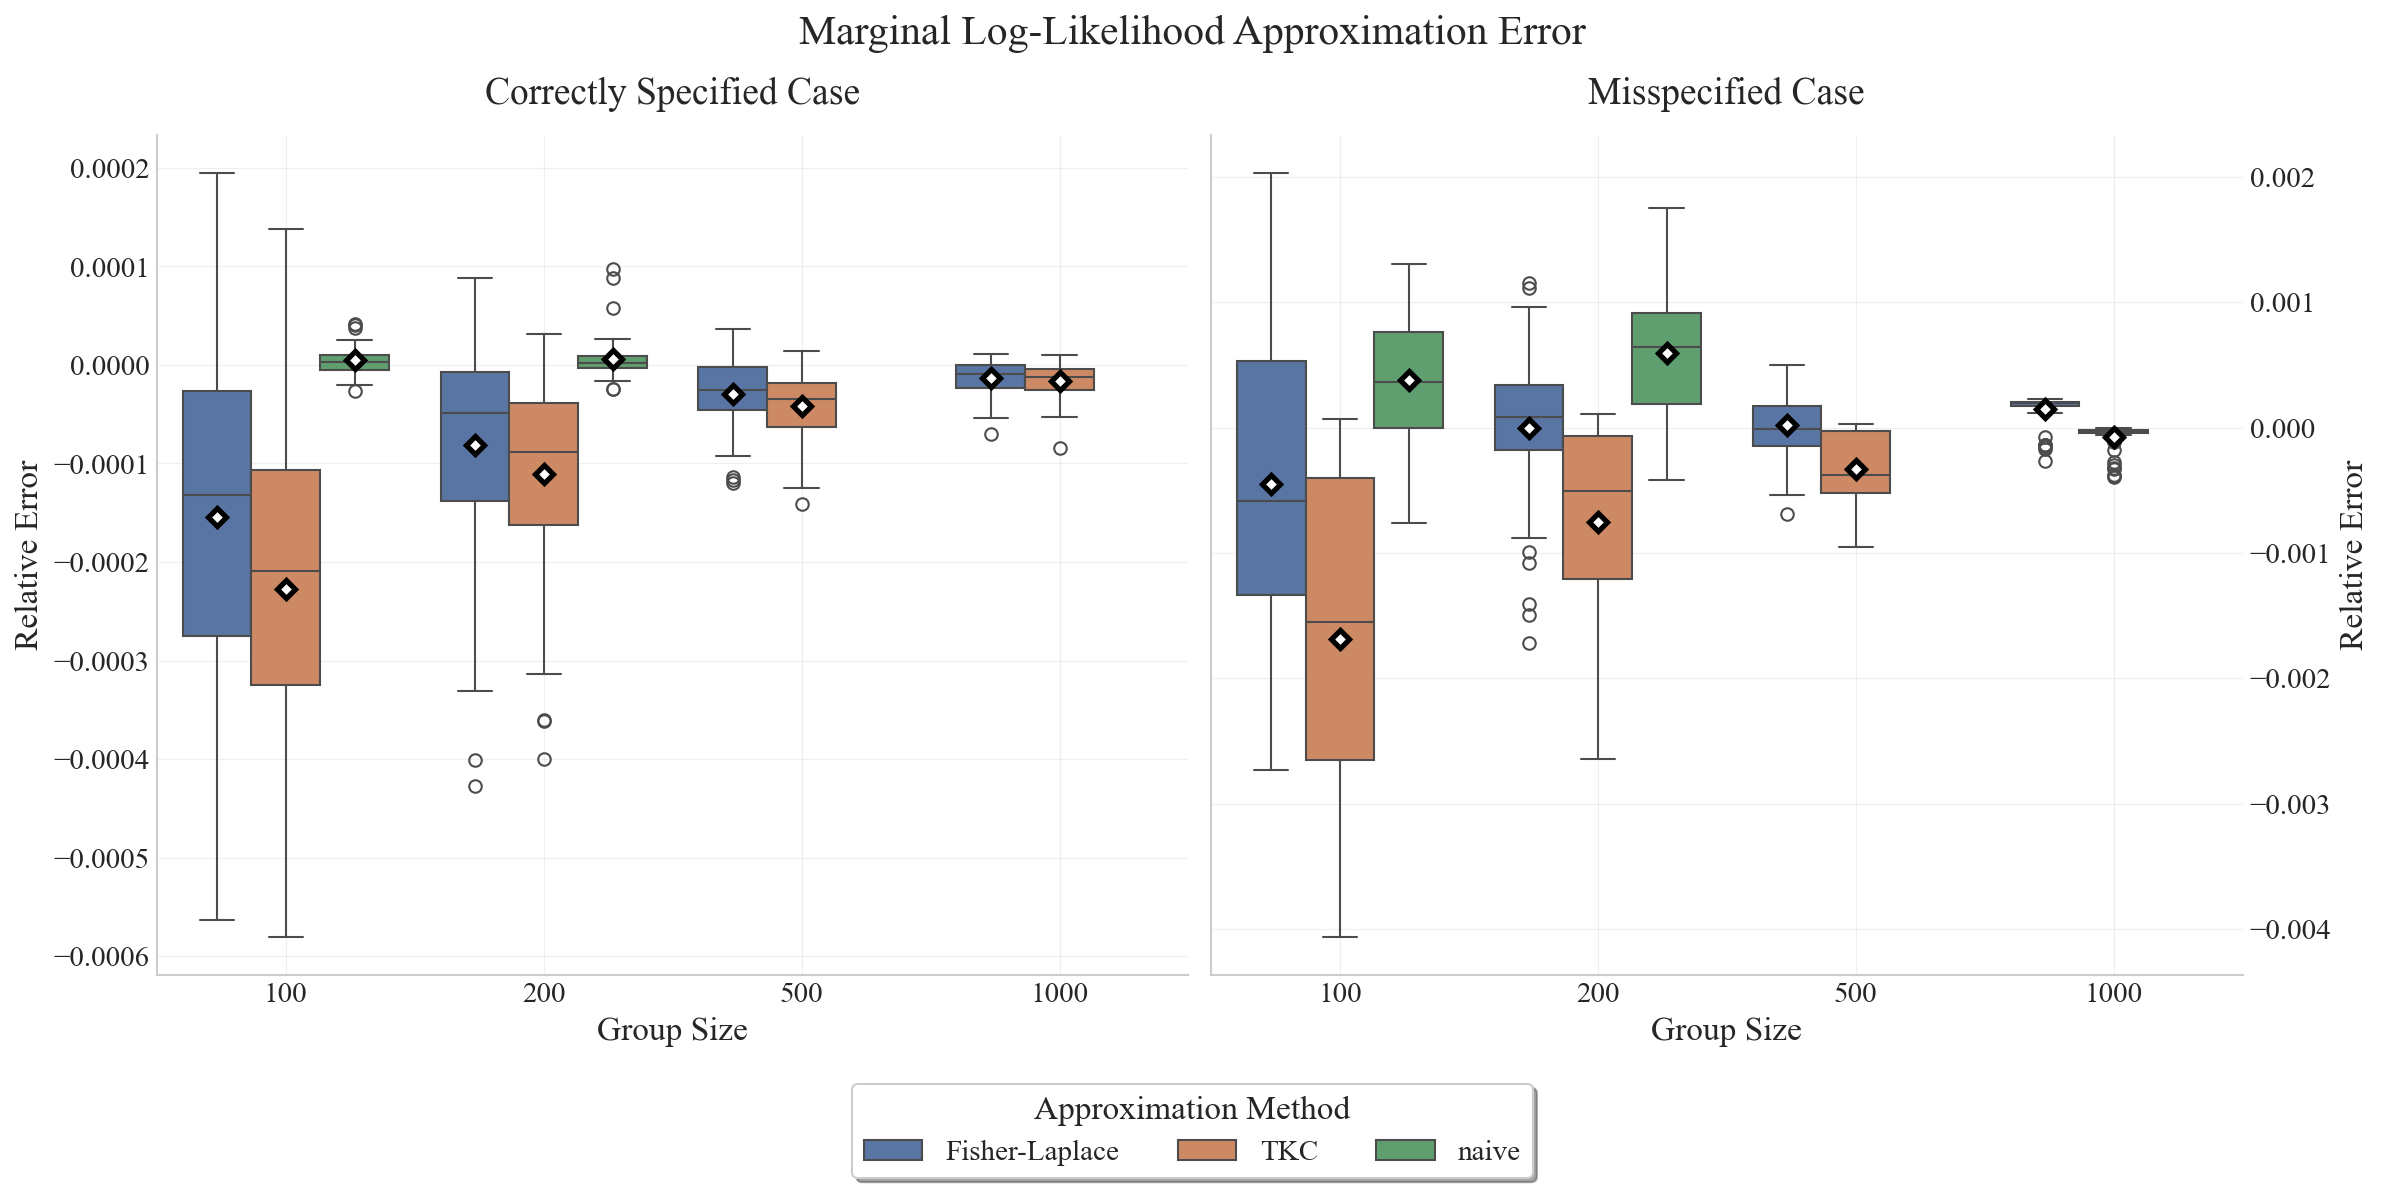

In [4]:
# Usage in notebook:
# Plot with estimate_scale=True
fig1 = plot_numerical_comparison()
